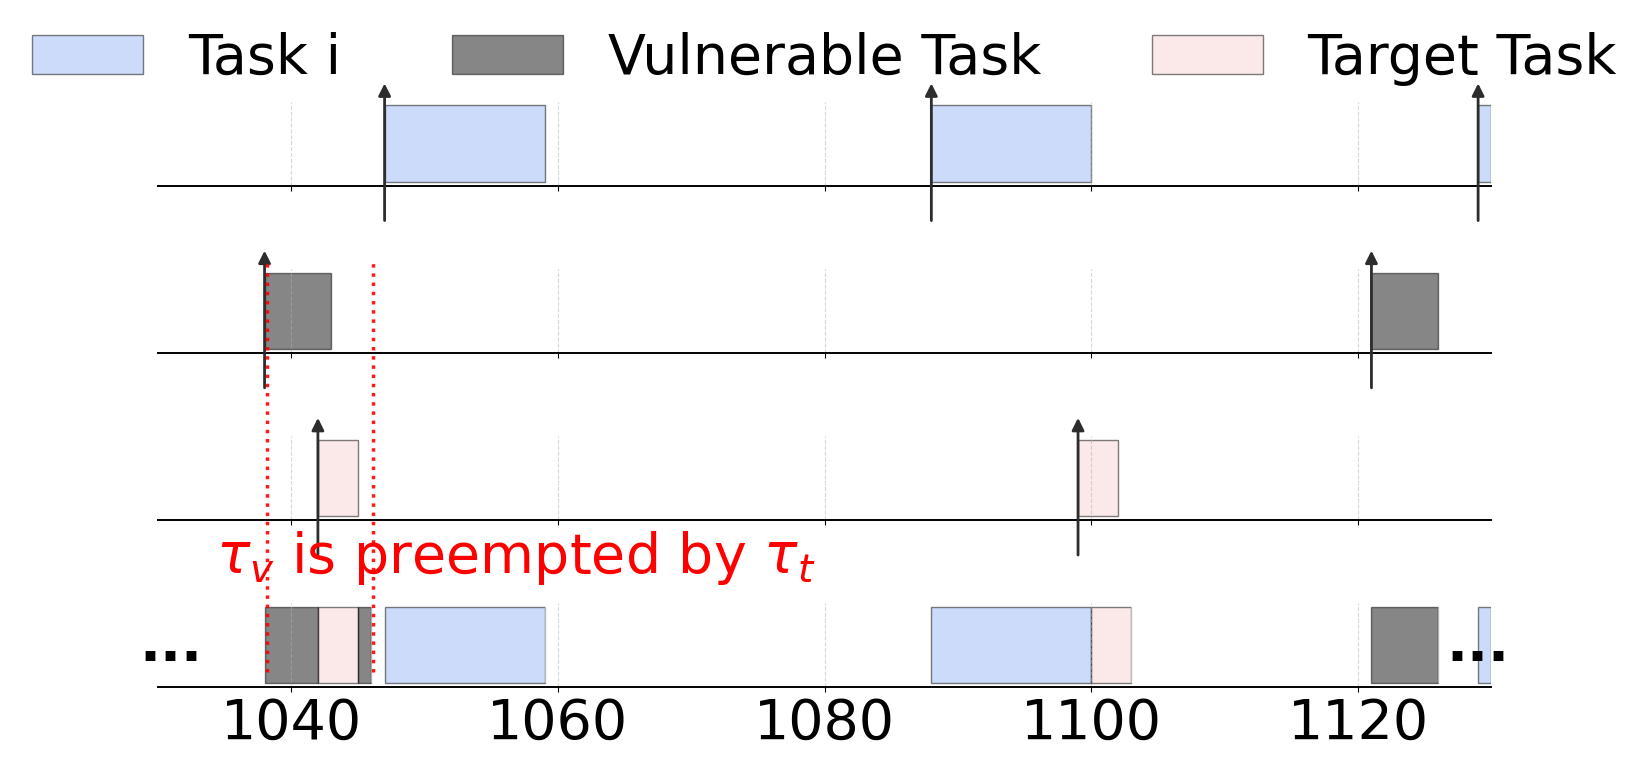

In [20]:
#!/usr/bin/env python3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

# =========================================================
# TIME WINDOW
# =========================================================
t0, t1 = 1030, 1130

# =========================================================
# STYLE
# =========================================================
FILL_ALPHA = 0.75
EDGE_COLOR = "black"
EDGE_LW = 1.0

ARROW_COLOR = "#2C2D2C"
ARROW_LW = 2
ARROW_HEAD = 18
ARROW_TAILY = 1.25
ARROW_TIPY = -0.45

XTICK_FS = 30+10
ELLIPSIS_FS = 30+10
LEGEND_FS = 30+10
LABEL_FS = 30+10

# =========================================================
# RED CONSTRAINT TIMES + TEXT
# =========================================================
RED_X_TIMES = [1038, 1046]
RED_COLOR = "red"
RED_LW = 2.5
RED_ALPHA = 0.9
PAD = 0.01

BLOCK_TEXT = r"$\tau_v$ is preempted by $\tau_t$"

FILL_ALPHA = 0.5  # or remove alpha=... in barh

colors = {
    "Task i": "#9BB9F5BF",
    "Vulnerable Task": "#0F0F0EBF",
    "Target Task": "#F9D2D2BF",
    "Idle": "#FFFFFF",
}

# ===== Task definitions =====
task_params = {
    'Task i': {'C': 12, 'period_seq': [
        89, 54, 75, 55, 70, 53, 57, 62, 57, 59, 28, 88, 76, 93, 54, 77, 41, 41, 62, 35,
        34, 53, 62, 86, 50, 62, 58, 41, 84, 81, 34, 29, 69, 64, 78, 44, 78, 90, 32, 78
    ]},
    'Target Task': {'C': 3, 'period_seq': [
        53, 61, 58, 66, 62, 70, 52, 68, 70, 56, 69, 58, 55, 56, 66, 66, 56, 57, 63, 65
    ]},
    'Vulnerable Task': {'C': 5, 'period_seq': [
        52, 43, 63, 79, 72, 82, 62, 78, 57, 82, 73, 57, 71, 62, 43, 62, 83, 65, 56, 49
    ]}
}

priority_order = ["Task i", "Target Task", "Vulnerable Task"]
priority_rank = {t: i for i, t in enumerate(priority_order)}

# =========================================================
# SIMULATION
# =========================================================
horizon = 4000
arrivals = {t: [] for t in priority_order}
schedule = []
next_release = {t: 0 for t in priority_order}
period_index = {t: 0 for t in priority_order}
job_queue = []

for t in range(horizon):
    for task in priority_order:
        if t == next_release[task]:
            C = task_params[task]["C"]
            seq = task_params[task]["period_seq"]
            k = period_index[task]
            P = seq[k % len(seq)]
            period_index[task] += 1
            next_release[task] = t + P
            arrivals[task].append((t, t + C))
            job_queue.append({"task": task, "remaining": C, "released": t})

    ready = [j for j in job_queue if j["remaining"] > 0 and j["released"] <= t]
    if ready:
        ready.sort(key=lambda j: priority_rank[j["task"]])
        ready[0]["remaining"] -= 1
        schedule.append((t, ready[0]["task"]))
    else:
        schedule.append((t, "Idle"))

# =========================================================
# EXECUTION BLOCKS
# =========================================================
execution_blocks = []
cur = schedule[0][1]
start = schedule[0][0]
for i in range(1, len(schedule)):
    if schedule[i][1] != cur:
        execution_blocks.append((start, schedule[i][0], cur))
        start = schedule[i][0]
        cur = schedule[i][1]
execution_blocks.append((start, horizon, cur))

# =========================================================
# HELPERS
# =========================================================
def clip(a, b):
    return (max(a, t0), min(b, t1)) if min(b, t1) > max(a, t0) else None

def ellipsis(ax, x):
    ax.text(x, 0, "...", fontsize=ELLIPSIS_FS,
            ha="center", va="center", weight="bold")

ARROW_BOTTOM = -0.45
ARROW_TOP    = 1.25


def arrows(ax, times):
    trans = ax.get_xaxis_transform()
    for x in times:
        if t0 <= x <= t1:
            ax.annotate("", xy=(x, ARROW_TOP), xytext=(x, ARROW_BOTTOM),
                        xycoords=trans, textcoords=trans,
                        arrowprops=dict(arrowstyle="-|>",
                                        color=ARROW_COLOR,
                                        linewidth=ARROW_LW,
                                        mutation_scale=ARROW_HEAD),
                        annotation_clip=False)

def draw_task(ax, task):
    for s, e in arrivals[task]:
        seg = clip(s, e)
        if seg:
            ax.barh(0, seg[1]-seg[0], left=seg[0], height=0.6,
                    facecolor=colors[task], alpha=FILL_ALPHA,
                    edgecolor=EDGE_COLOR, linewidth=EDGE_LW)
            # remove ellipsis from here
            # if s < t0: ellipsis(ax, t0 + 1)
            # if e > t1: ellipsis(ax, t1 - 1)
    arrows(ax, [a for a,_ in arrivals[task]])
    ax.set_xlim(t0, t1)
    ax.set_yticks([])

def draw_schedule(ax):
    for s, e, task in execution_blocks:
        seg = clip(s, e)
        if seg:
            ax.barh(0, seg[1]-seg[0], left=seg[0], height=0.6,
                    facecolor=colors.get(task,"#fff"),
                    edgecolor=EDGE_COLOR if task!="Idle" else "none",
                    linewidth=EDGE_LW if task!="Idle" else 0,
                    alpha=FILL_ALPHA)
            if s < t0: ellipsis(ax, t0 + 1)
            if e > t1: ellipsis(ax, t1 - 1)
    ax.set_xlim(t0, t1)
    ax.set_yticks([])

# =========================================================
# PLOT
# =========================================================
fig, axs = plt.subplots(4, 1, figsize=(14,7), sharex=True)
fig.subplots_adjust(hspace=1.4)

draw_task(axs[0], "Task i")
draw_task(axs[1], "Vulnerable Task")
draw_task(axs[2], "Target Task")
draw_schedule(axs[3])

# =========================================================
# AXIS STYLE
# =========================================================
for ax in axs:
    ax.xaxis.set_major_locator(MultipleLocator(20))
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.4)
    ax.tick_params(left=False)

axs[-1].tick_params(axis="x", labelsize=XTICK_FS)

plt.tight_layout()

# =========================================================
# RED LINES + TEXT BLOCK (FIGURE LEVEL)
# =========================================================
vuln_ax = axs[1]
target_ax = axs[2]
x_figs = []

for t in RED_X_TIMES:
    x_disp = vuln_ax.transData.transform((t, 0))[0]
    x_fig = fig.transFigure.inverted().transform((x_disp, 0))[0]
    x_figs.append(x_fig)

    y0 = target_ax.get_position().y0 + PAD-0.22
    y1 = vuln_ax.get_position().y1 - PAD

    fig.add_artist(
        Line2D([x_fig, x_fig], [y0, y1],
               transform=fig.transFigure,
               color=RED_COLOR,
               linewidth=RED_LW,
               linestyle=":",
               alpha=RED_ALPHA,
               zorder=30)
    )

# --- Centered text block ---
x_center = sum(x_figs) / len(x_figs)+0.14
y_mid = 0.5 * (y0 + y1)-.13

fig.text(
    x_center, y_mid,
    BLOCK_TEXT,
    fontsize=LABEL_FS,
    ha="center", va="center",
    color="red",
    bbox=dict(facecolor="none", edgecolor="none", pad=0.3)
)

# =========================================================
# LEGEND (TASKS ONLY)
# =========================================================
legend_handles = [
    mpatches.Patch(facecolor=colors["Task i"], edgecolor=EDGE_COLOR,
                   linewidth=EDGE_LW, alpha=FILL_ALPHA, label="Task i"),
    mpatches.Patch(facecolor=colors["Vulnerable Task"], edgecolor=EDGE_COLOR,
                   linewidth=EDGE_LW, alpha=FILL_ALPHA, label="Vulnerable Task"),
    mpatches.Patch(facecolor=colors["Target Task"], edgecolor=EDGE_COLOR,
                   linewidth=EDGE_LW, alpha=FILL_ALPHA, label="Target Task"),
]
fig.legend(handles=legend_handles,
           loc="upper center",
           ncol=3,
           fontsize=LEGEND_FS,
           frameon=False,
           bbox_to_anchor=(0.5, 1.12))

plt.savefig("continuous_constraint_lines_with_text_block.pdf",
            bbox_inches="tight")
plt.tight_layout()
plt.savefig("pincer_case.pdf", format='pdf', bbox_inches='tight')
plt.show()


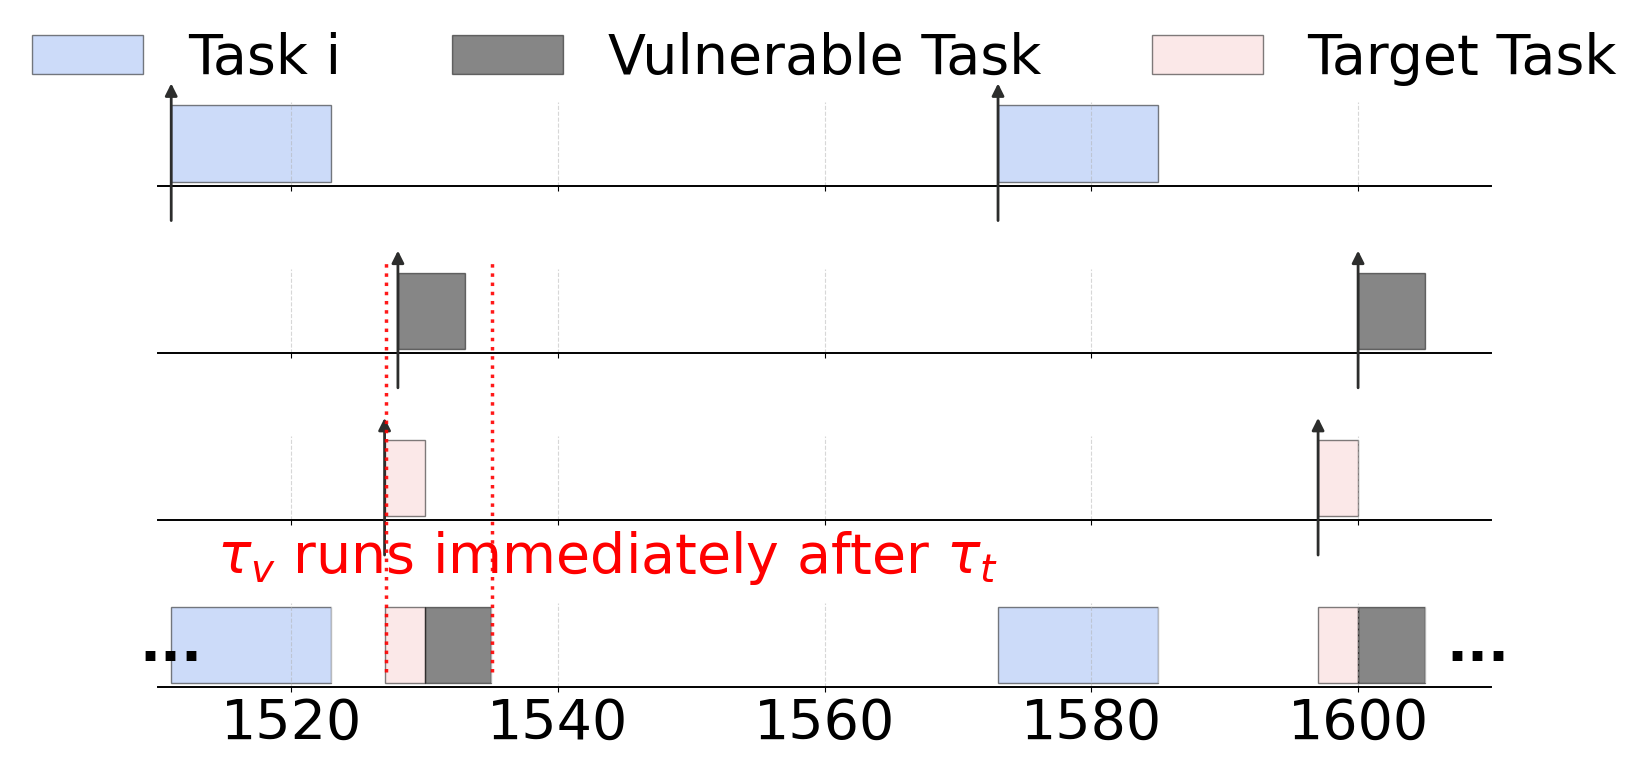

In [16]:
#!/usr/bin/env python3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

# =========================================================
# TIME WINDOW
# =========================================================
t0, t1 = 1510, 1610

# =========================================================
# STYLE
# =========================================================
FILL_ALPHA = 0.75
EDGE_COLOR = "black"
EDGE_LW = 1.0

ARROW_COLOR = "#2C2D2C"
ARROW_LW = 1.5+0.5
ARROW_HEAD = 12+6
ARROW_TAILY = 1.25
ARROW_TIPY = -0.45

XTICK_FS = 30+10
ELLIPSIS_FS = 30+10
LEGEND_FS = 30+10
LABEL_FS = 30+10

# =========================================================
# RED CONSTRAINT TIMES + TEXT
# =========================================================
RED_X_TIMES = [1527,1535]
RED_COLOR = "red"
RED_LW = 2.5
RED_ALPHA = 0.9
PAD = 0.01

BLOCK_TEXT = r"$\tau_v$ runs immediately after $\tau_t$"

FILL_ALPHA = 0.5  # or remove alpha=... in barh

colors = {
    "Task i": "#9BB9F5BF",
    "Vulnerable Task": "#0F0F0EBF",
    "Target Task": "#F9D2D2BF",
    "Idle": "#FFFFFF",
}

# ===== Task definitions =====
task_params = {
    'Task i': {'C': 12, 'period_seq': [
        89, 54, 75, 55, 70, 53, 57, 62, 57, 59, 28, 88, 76, 93, 54, 77, 41, 41, 62, 35,
        34, 53, 62, 86, 50, 62, 58, 41, 84, 81, 34, 29, 69, 64, 78, 44, 78, 90, 32, 78
    ]},
    'Target Task': {'C': 3, 'period_seq': [
        53, 61, 58, 66, 62, 70, 52, 68, 70, 56, 69, 58, 55, 56, 66, 66, 56, 57, 63, 65
    ]},
    'Vulnerable Task': {'C': 5, 'period_seq': [
        52, 43, 63, 79, 72, 82, 62, 78, 57, 82, 73, 57, 71, 62, 43, 62, 83, 65, 56, 49
    ]}
}


priority_order = ['Task i', 'Target Task', 'Vulnerable Task']
priority_rank = {t: i for i, t in enumerate(priority_order)}

# =========================================================
# SIMULATION
# =========================================================
horizon = 4000
arrivals = {t: [] for t in priority_order}
schedule = []
next_release = {t: 0 for t in priority_order}
period_index = {t: 0 for t in priority_order}
job_queue = []

for t in range(horizon):
    for task in priority_order:
        if t == next_release[task]:
            C = task_params[task]["C"]
            seq = task_params[task]["period_seq"]
            k = period_index[task]
            P = seq[k % len(seq)]
            period_index[task] += 1
            next_release[task] = t + P
            arrivals[task].append((t, t + C))
            job_queue.append({"task": task, "remaining": C, "released": t})

    ready = [j for j in job_queue if j["remaining"] > 0 and j["released"] <= t]
    if ready:
        ready.sort(key=lambda j: priority_rank[j["task"]])
        ready[0]["remaining"] -= 1
        schedule.append((t, ready[0]["task"]))
    else:
        schedule.append((t, "Idle"))

# =========================================================
# EXECUTION BLOCKS
# =========================================================
execution_blocks = []
cur = schedule[0][1]
start = schedule[0][0]
for i in range(1, len(schedule)):
    if schedule[i][1] != cur:
        execution_blocks.append((start, schedule[i][0], cur))
        start = schedule[i][0]
        cur = schedule[i][1]
execution_blocks.append((start, horizon, cur))

# =========================================================
# HELPERS
# =========================================================
def clip(a, b):
    return (max(a, t0), min(b, t1)) if min(b, t1) > max(a, t0) else None

def ellipsis(ax, x):
    ax.text(x, 0, "...", fontsize=ELLIPSIS_FS,
            ha="center", va="center", weight="bold")

ARROW_BOTTOM = -0.45
ARROW_TOP    = 1.25

def arrows(ax, times):
    trans = ax.get_xaxis_transform()
    for x in times:
        if t0 <= x <= t1:
            ax.annotate("", xy=(x, ARROW_TOP), xytext=(x, ARROW_BOTTOM),
                        xycoords=trans, textcoords=trans,
                        arrowprops=dict(arrowstyle="-|>",
                                        color=ARROW_COLOR,
                                        linewidth=ARROW_LW,
                                        mutation_scale=ARROW_HEAD),
                        annotation_clip=False)

def draw_task(ax, task):
    for s, e in arrivals[task]:
        seg = clip(s, e)
        if seg:
            ax.barh(0, seg[1]-seg[0], left=seg[0], height=0.6,
                    facecolor=colors[task], alpha=FILL_ALPHA,
                    edgecolor=EDGE_COLOR, linewidth=EDGE_LW)
            if s < t0: ellipsis(ax, t0 + 1)
            if e > t1: ellipsis(ax, t1 - 1)
    arrows(ax, [a for a,_ in arrivals[task]])
    ax.set_xlim(t0, t1)
    ax.set_yticks([])

def draw_schedule(ax):
    for s, e, task in execution_blocks:
        seg = clip(s, e)
        if seg:
            ax.barh(0, seg[1]-seg[0], left=seg[0], height=0.6,
                    facecolor=colors.get(task,"#fff"),
                    edgecolor=EDGE_COLOR if task!="Idle" else "none",
                    linewidth=EDGE_LW if task!="Idle" else 0,
                    alpha=FILL_ALPHA)
            if s < t0: ellipsis(ax, t0 + 1)
            if e > t1: ellipsis(ax, t1 - 1)
    ax.set_xlim(t0, t1)
    ax.set_yticks([])

# =========================================================
# PLOT
# =========================================================
fig, axs = plt.subplots(4, 1, figsize=(14,7), sharex=True)
fig.subplots_adjust(hspace=1.4)

draw_task(axs[0], "Task i")
draw_task(axs[1], "Vulnerable Task")
draw_task(axs[2], "Target Task")
draw_schedule(axs[3])

# =========================================================
# AXIS STYLE
# =========================================================
for ax in axs:
    ax.xaxis.set_major_locator(MultipleLocator(20))
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.4)
    ax.tick_params(left=False)

axs[-1].tick_params(axis="x", labelsize=XTICK_FS)

plt.tight_layout()

# =========================================================
# RED LINES + TEXT BLOCK (FIGURE LEVEL)
# =========================================================
vuln_ax = axs[1]
target_ax = axs[2]
x_figs = []

for t in RED_X_TIMES:
    x_disp = vuln_ax.transData.transform((t, 0))[0]
    x_fig = fig.transFigure.inverted().transform((x_disp, 0))[0]
    x_figs.append(x_fig)

    y0 = target_ax.get_position().y0 + PAD-0.22
    y1 = vuln_ax.get_position().y1 - PAD

    fig.add_artist(
        Line2D([x_fig, x_fig], [y0, y1],
               transform=fig.transFigure,
               color=RED_COLOR,
               linewidth=RED_LW,
               linestyle=":",
               alpha=RED_ALPHA,
               zorder=30)
    )

# --- Centered text block ---
x_center = sum(x_figs) / len(x_figs)+0.12
y_mid = 0.5 * (y0 + y1)-.13

fig.text(
    x_center, y_mid,
    BLOCK_TEXT,
    fontsize=LABEL_FS,
    ha="center", va="center",
    color="red",
    bbox=dict(facecolor="none", edgecolor="none", pad=0.3)
)

# =========================================================
# LEGEND (TASKS ONLY)
# =========================================================
legend_handles = [
    mpatches.Patch(facecolor=colors["Task i"], edgecolor=EDGE_COLOR,
                   linewidth=EDGE_LW, alpha=FILL_ALPHA, label="Task i"),
    mpatches.Patch(facecolor=colors["Vulnerable Task"], edgecolor=EDGE_COLOR,
                   linewidth=EDGE_LW, alpha=FILL_ALPHA, label="Vulnerable Task"),
    mpatches.Patch(facecolor=colors["Target Task"], edgecolor=EDGE_COLOR,
                   linewidth=EDGE_LW, alpha=FILL_ALPHA, label="Target Task"),
]

fig.legend(handles=legend_handles,
           loc="upper center",
           ncol=3,
           fontsize=LEGEND_FS,
           frameon=False,
           bbox_to_anchor=(0.5, 1.12))

plt.savefig("continuous_constraint_lines_with_text_block.pdf",
            bbox_inches="tight")
plt.tight_layout()
plt.savefig("posterior_immediate_case.pdf", format='pdf', bbox_inches='tight')
plt.show()
